In [19]:
import pandas as pd
import numpy as np

In [20]:
marketing_data=pd.read_csv('marketing_campaign_dataset.csv')
marketing_data.head(15)

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05
5,6,DataTech Solutions,Display,All Ages,15 days,Instagram,0.07,"$9,716.00",4.36,New York,German,100,1643,1,Foodies,2021-01-06
6,7,NexGen Systems,Email,Women 35-44,60 days,Website,0.13,"$11,067.00",2.86,Los Angeles,Spanish,817,8749,10,Tech Enthusiasts,2021-01-07
7,8,DataTech Solutions,Search,Men 18-24,45 days,Google Ads,0.08,"$13,280.00",5.55,Los Angeles,Mandarin,624,7854,7,Outdoor Adventurers,2021-01-08
8,9,Alpha Innovations,Social Media,Women 35-44,15 days,Facebook,0.09,"$18,066.00",6.73,Chicago,German,861,1754,6,Tech Enthusiasts,2021-01-09
9,10,TechCorp,Email,Women 35-44,15 days,Instagram,0.09,"$13,766.00",3.78,Los Angeles,English,642,3856,3,Tech Enthusiasts,2021-01-10


In [21]:
marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [22]:
#Let's turn date around
marketing_data['Date']=pd.to_datetime(marketing_data['Date']) 
marketing_data['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 200000 entries, 0 to 199999
Series name: Date
Non-Null Count   Dtype         
--------------   -----         
200000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.5 MB


In [23]:
# Convert Acquisition_Cost to a number ,clean it if there are characters
marketing_data['Acquisition_Cost']=marketing_data['Acquisition_Cost'].replace(r'[\$,]','',regex=True).astype(float)
marketing_data['Acquisition_Cost']

0         16174.0
1         11566.0
2         10200.0
3         12724.0
4         16452.0
           ...   
199995    18365.0
199996     8168.0
199997    13397.0
199998    18508.0
199999    13835.0
Name: Acquisition_Cost, Length: 200000, dtype: float64

In [24]:
#delete  unnecessary columns
marketing_data=marketing_data.drop(['Campaign_ID','Company','Language'],axis=1)
marketing_data.head(10)

,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,Email,Men 18-24,30 days,Google Ads,0.04,16174.0,6.29,Chicago,506,1922,6,Health & Wellness,2021-01-01
1,Email,Women 35-44,60 days,Google Ads,0.12,11566.0,5.61,New York,116,7523,7,Fashionistas,2021-01-02
2,Influencer,Men 25-34,30 days,YouTube,0.07,10200.0,7.18,Los Angeles,584,7698,1,Outdoor Adventurers,2021-01-03
3,Display,All Ages,60 days,YouTube,0.11,12724.0,5.55,Miami,217,1820,7,Health & Wellness,2021-01-04
4,Email,Men 25-34,15 days,YouTube,0.05,16452.0,6.50,Los Angeles,379,4201,3,Health & Wellness,2021-01-05
5,Display,All Ages,15 days,Instagram,0.07,9716.0,4.36,New York,100,1643,1,Foodies,2021-01-06
6,Email,Women 35-44,60 days,Website,0.13,11067.0,2.86,Los Angeles,817,8749,10,Tech Enthusiasts,2021-01-07
7,Search,Men 18-24,45 days,Google Ads,0.08,13280.0,5.55,Los Angeles,624,7854,7,Outdoor Adventurers,2021-01-08
8,Social Media,Women 35-44,15 days,Facebook,0.09,18066.0,6.73,Chicago,861,1754,6,Tech Enthusiasts,2021-01-09
9,Email,Women 35-44,15 days,Instagram,0.09,13766.0,3.78,Los Angeles,642,3856,3,Tech Enthusiasts,2021-01-10


In [25]:
campaign_counts=marketing_data['Campaign_Type'].value_counts()
print("--- Campaign Type Distribution ---")
print(campaign_counts)


--- Campaign Type Distribution ---
Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64


In [30]:
#create a time series for each campaign type
#ths groups the data by Date and calculates average ROI for each campaign type daily
causal_input=marketing_data.pivot_table(index='Date',
                                        columns='Campaign_Type',
                                        values='ROI',
                                        aggfunc='mean')
#handle missing dates or values
# ffill() fills gaps with the previous day's value to ensure the timeline is unbroken
causal_input=causal_input.ffill().dropna()

# 3. Format for CausalImpact: The first column MUST be the 'Treated' group
# Since 'Influencer' is our focus, we put it first. The others act as 'Controls'.
cols=['Influencer']+[c for c in causal_input.columns if c!='Influencer']
causal_input=causal_input[cols]

print("--- Prepared Data (First 5 Days) ---")
print(causal_input.head())

--- Prepared Data (First 5 Days) ---
Campaign_Type  Influencer   Display     Email    Search  Social Media
Date                                                                 
2021-01-01       4.803301  5.211417  5.157885  5.055392      4.961786
2021-01-02       5.486304  5.089174  4.682650  4.971826      4.908696
2021-01-03       5.128222  4.884196  5.023585  4.801938      5.277027
2021-01-04       4.871827  5.049914  4.966139  5.470270      5.118879
2021-01-05       4.804124  4.864609  4.811308  4.755200      4.967264


In [33]:
!pip install pycausalimpact
from causalimpact import CausalImpact
#define the pre-period and post-period
#pre-period- data before the campaign (e.g., first 7 months)
#post period- data after the campaign started (e.g., last 5 months)
#let's assume the campaign started on July 1st, 2021
pre_period=['2021-01-01', '2021-06-30']
post_period=['2021-07-01', '2021-12-31']

C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, appro

--- Generating Causal Impact Visualization ---


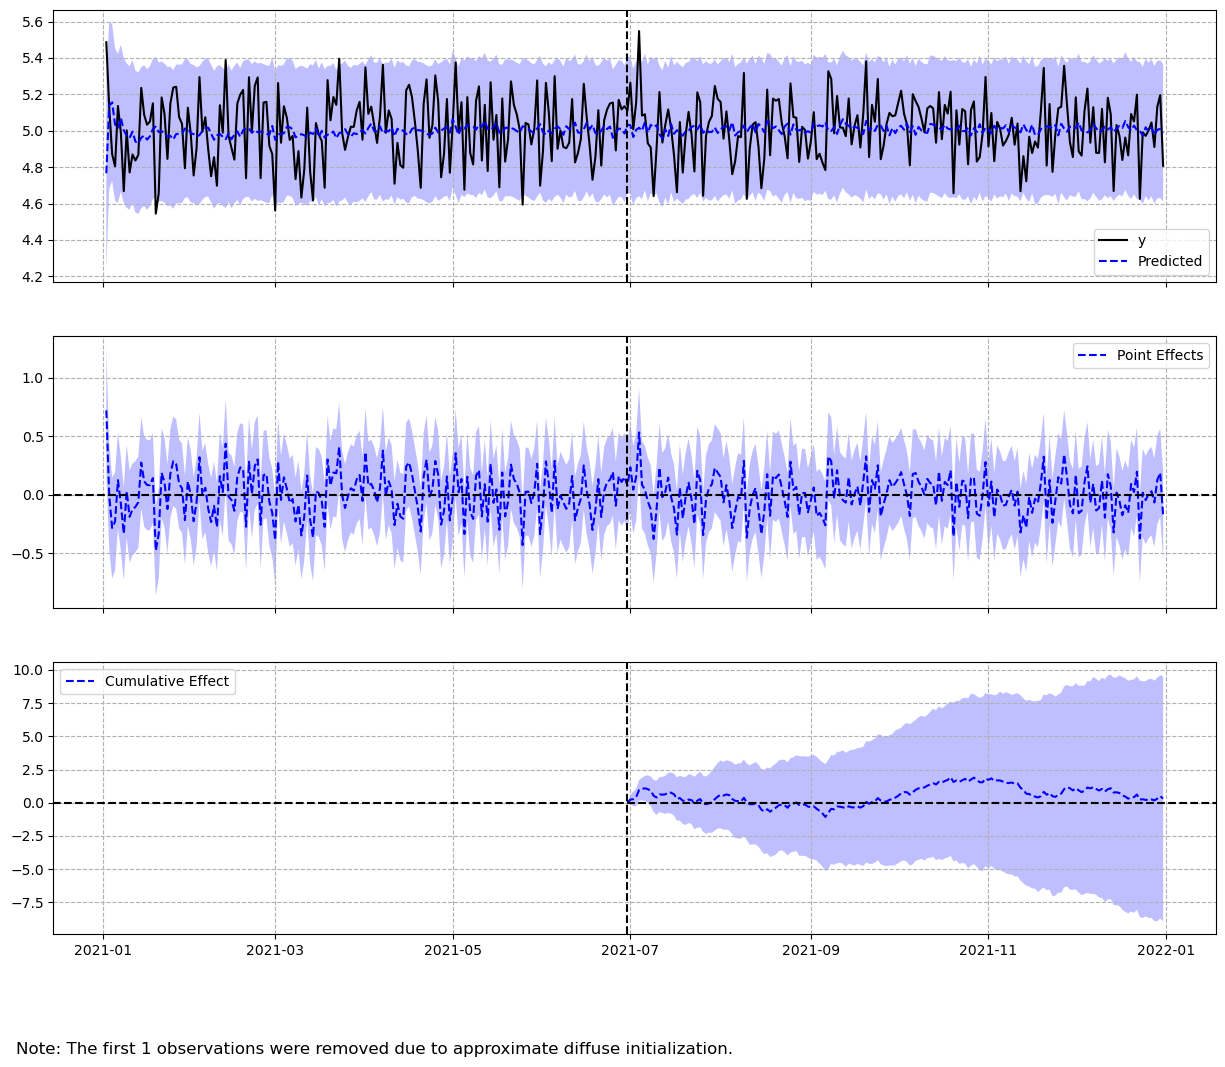

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    5.01               922.21
Prediction (s.d.)         5.01 (0.03)        921.9 (4.71)
95% CI                    [4.96, 5.06]       [912.7, 931.16]

Absolute effect (s.d.)    0.0 (0.03)         0.31 (4.71)
95% CI                    [-0.05, 0.05]      [-8.95, 9.52]

Relative effect (s.d.)    0.03% (0.51%)      0.03% (0.51%)
95% CI                    [-0.97%, 1.03%]    [-0.97%, 1.03%]

Posterior tail-area probability p: 0.48
Posterior prob. of a causal effect: 52.15%

For more details run the command: print(impact.summary('report'))


In [34]:
# Run CausalImpact
# it will compare 'Influencer' with the other columns automatically
ci=CausalImpact(causal_input,pre_period,post_period)

# This will show the actual ROI vs. what it would have been without the campaign
print("--- Generating Causal Impact Visualization ---")
ci.plot()

#print the summary report
print(ci.summary())

C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, appro

--- Social Media Campaign Causal Analysis ---


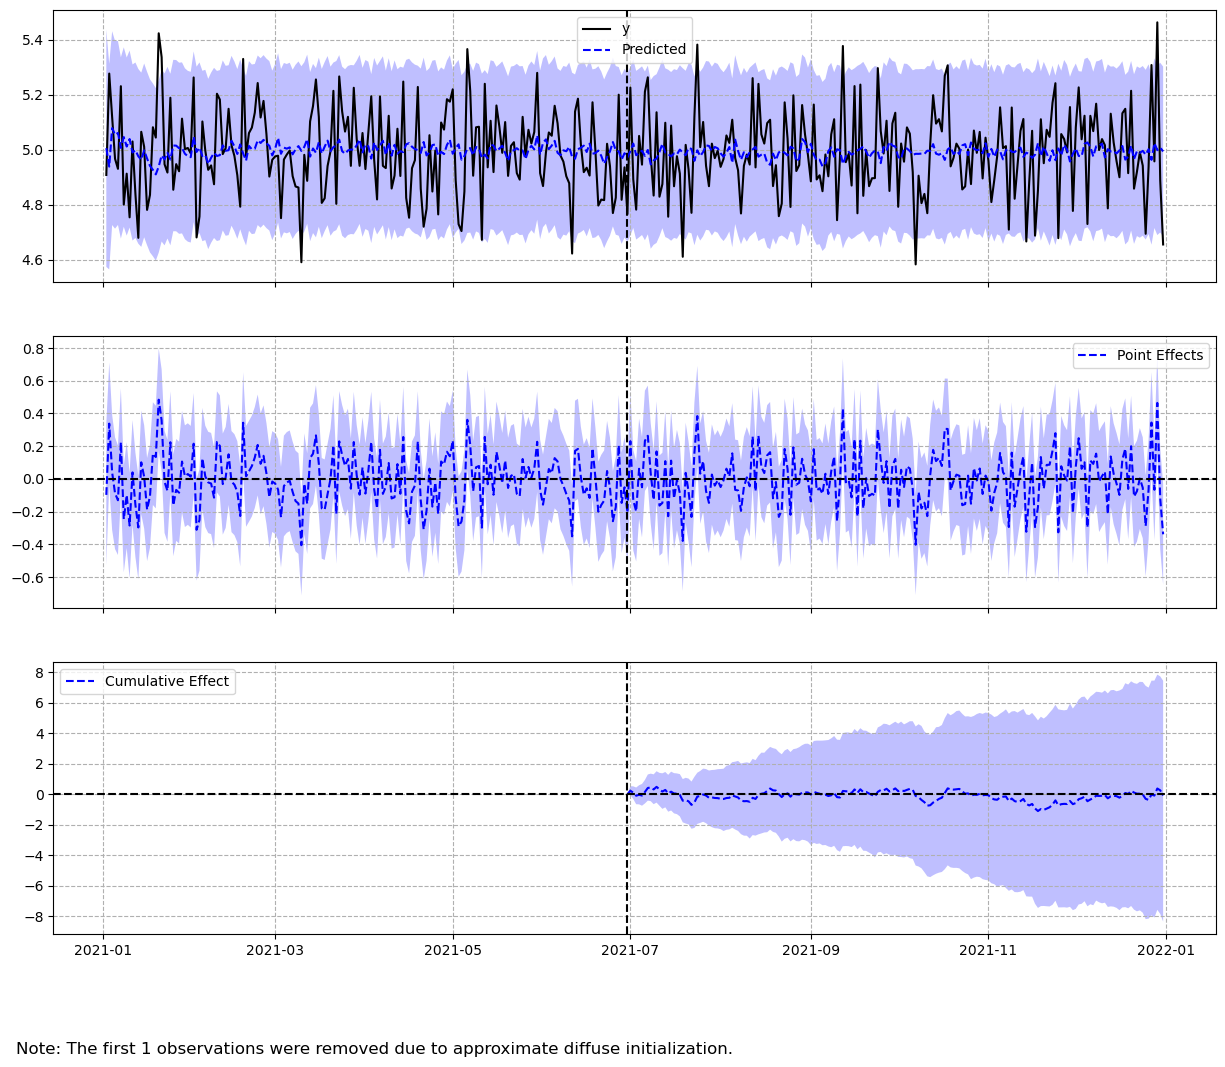

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    4.99               918.32
Prediction (s.d.)         4.99 (0.02)        918.4 (4.03)
95% CI                    [4.95, 5.04]       [910.89, 926.67]

Absolute effect (s.d.)    -0.0 (0.02)        -0.08 (4.03)
95% CI                    [-0.05, 0.04]      [-8.34, 7.44]

Relative effect (s.d.)    -0.01% (0.44%)     -0.01% (0.44%)
95% CI                    [-0.91%, 0.81%]    [-0.91%, 0.81%]

Posterior tail-area probability p: 0.49
Posterior prob. of a causal effect: 51.25%

For more details run the command: print(impact.summary('report'))
Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 4.99. In the absence of an
intervention, we would have expected an average response of 4.99.
The 95% interval of this counterfactual prediction is [4.95, 5.04].
Subtracting this prediction from the observed response yield

In [36]:
import pandas as pd
from causalimpact import CausalImpact

# prepare Data-Pivot and set 'Social Media' as the treated group (first column)
causal_input_sm = marketing_data.pivot_table(index='Date', columns='Campaign_Type', values='ROI', aggfunc='mean')
causal_input_sm = causal_input_sm.ffill().dropna()
cols_sm = ['Social Media'] + [c for c in causal_input_sm.columns if c != 'Social Media']
causal_input_sm = causal_input_sm[cols_sm]

#define Intervention periods (pre: Jan-June,post: July-Dec)
pre_period = ['2021-01-01', '2021-06-30']
post_period = ['2021-07-01', '2021-12-31']

#run CausalImpact Model
ci_sm = CausalImpact(causal_input_sm, pre_period, post_period)

# generate outputs
print("--- Social Media Campaign Causal Analysis ---")
ci_sm.plot()
print(ci_sm.summary())
print(ci_sm.summary('report'))

DID Estimated Effect: -0.020333663818029812


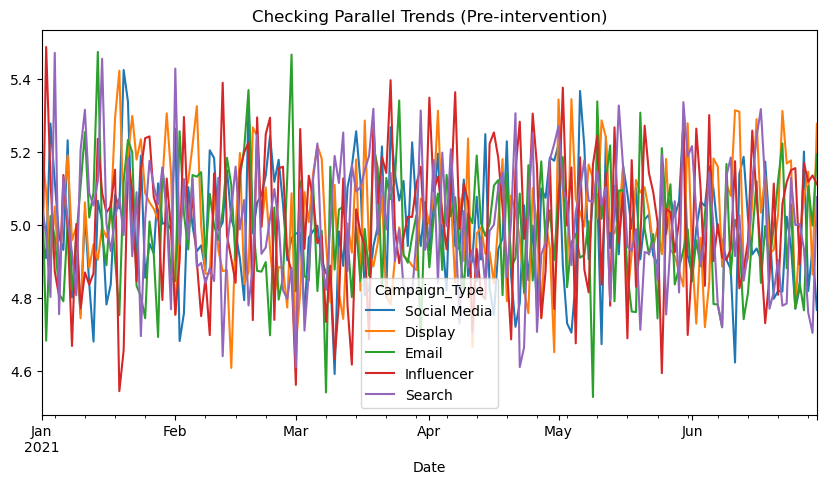

In [37]:
# DID Calculation (Simple Form)
pre_mean_treated=causal_input_sm.loc[pre_period[0]:pre_period[1], 'Social Media'].mean()
post_mean_treated=causal_input_sm.loc[post_period[0]:post_period[1], 'Social Media'].mean()

pre_mean_control=causal_input_sm.loc[pre_period[0]:pre_period[1], 'Email'].mean()
post_mean_control=causal_input_sm.loc[post_period[0]:post_period[1], 'Email'].mean()
did_effect=(post_mean_treated-pre_mean_treated)-(post_mean_control-pre_mean_control)
print(f"DID Estimated Effect: {did_effect}")

#Parallel Trends Visualization
causal_input_sm.loc[pre_period[0]:pre_period[1]].plot(figsize=(10,5))
import matplotlib.pyplot as plt
plt.title("Checking Parallel Trends (Pre-intervention)")
plt.show()

In [38]:
# DID Calculation
# (Post_Treated - Pre_Treated) - (Post_Control - Pre_Control)
pre_period = ('2021-01-01', '2021-06-30')
post_period = ('2021-07-01', '2021-12-31')

# We'll use Social Media as Treated and Email as Control
did_res = (causal_input_sm.loc[post_period[0]:post_period[1], 'Social Media'].mean() - 
           causal_input_sm.loc[pre_period[0]:pre_period[1], 'Social Media'].mean()) - \
          (causal_input_sm.loc[post_period[0]:post_period[1], 'Email'].mean() - 
           causal_input_sm.loc[pre_period[0]:pre_period[1], 'Email'].mean())

print(f"Difference-in-Differences (DID) Estimated Effect: {did_res}")

Difference-in-Differences (DID) Estimated Effect: -0.020333663818029812


In [43]:
import numpy as np

# Checking the stability of ATE in different samples (Bootstrapping)
bootstrapped_effects = []
for _ in range(100):
    sample = causal_input_sm.sample(frac=1.0, replace=True).sort_index()
    pre = sample.loc[pre_period[0]:pre_period[1], 'Social Media'].mean()
    post = sample.loc[post_period[0]:post_period[1], 'Social Media'].mean()
    bootstrapped_effects.append(post - pre)

print(f"Mean Bootstrapped Effect: {np.mean(bootstrapped_effects)}")
print(f"Effect Stability (Std Dev): {np.std(bootstrapped_effects)}")

Mean Bootstrapped Effect: -0.004697415690030144
Effect Stability (Std Dev): 0.016049346903238566


--- RUNNING SIMULATED LIFT ANALYSIS ---


C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, appro

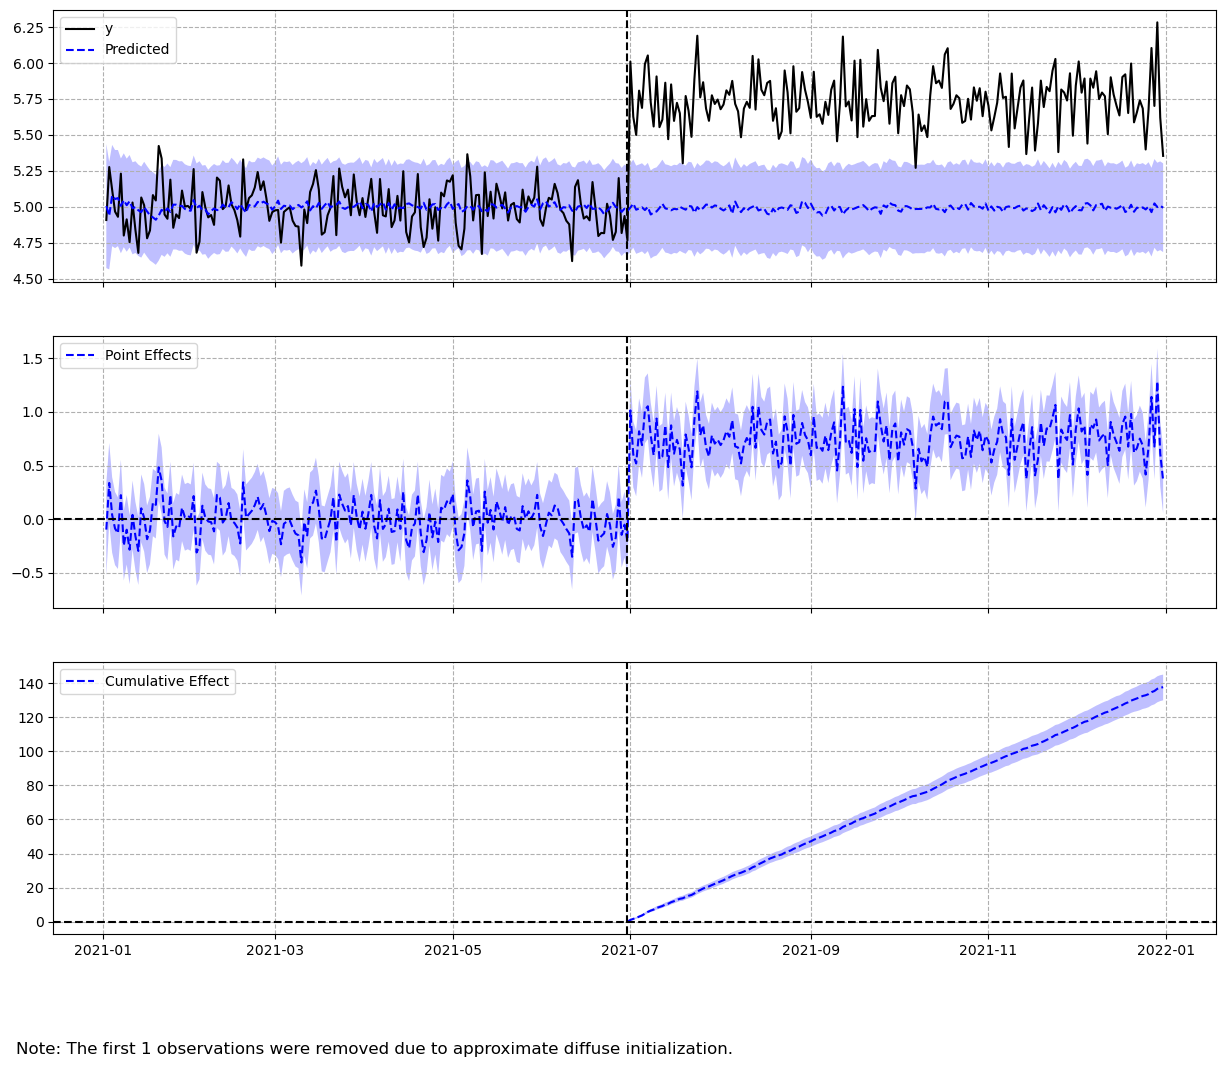

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    5.74               1056.07
Prediction (s.d.)         4.99 (0.02)        918.4 (3.86)
95% CI                    [4.95, 5.03]       [911.02, 926.14]

Absolute effect (s.d.)    0.75 (0.02)        137.67 (3.86)
95% CI                    [0.71, 0.79]       [129.93, 145.05]

Relative effect (s.d.)    14.99% (0.42%)     14.99% (0.42%)
95% CI                    [14.15%, 15.79%]   [14.15%, 15.79%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [46]:
# --- SCENARIO B: Successful Campaign Simulation ---
pre_period = ['2021-01-01', '2021-06-30']
post_period = ['2021-07-01', '2021-12-31']
print("--- RUNNING SIMULATED LIFT ANALYSIS ---")
causal_input_simulated = causal_input_sm.copy()
# We artificially increase it by 15%
causal_input_simulated.loc[post_period[0]:, 'Social Media'] *= 1.15

ci_sim = CausalImpact(causal_input_simulated, pre_period, post_period)
ci_sim.plot()
print(ci_sim.summary())

C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, appro


--- REGIONAL CAUSAL ANALYSIS SUMMARY ---


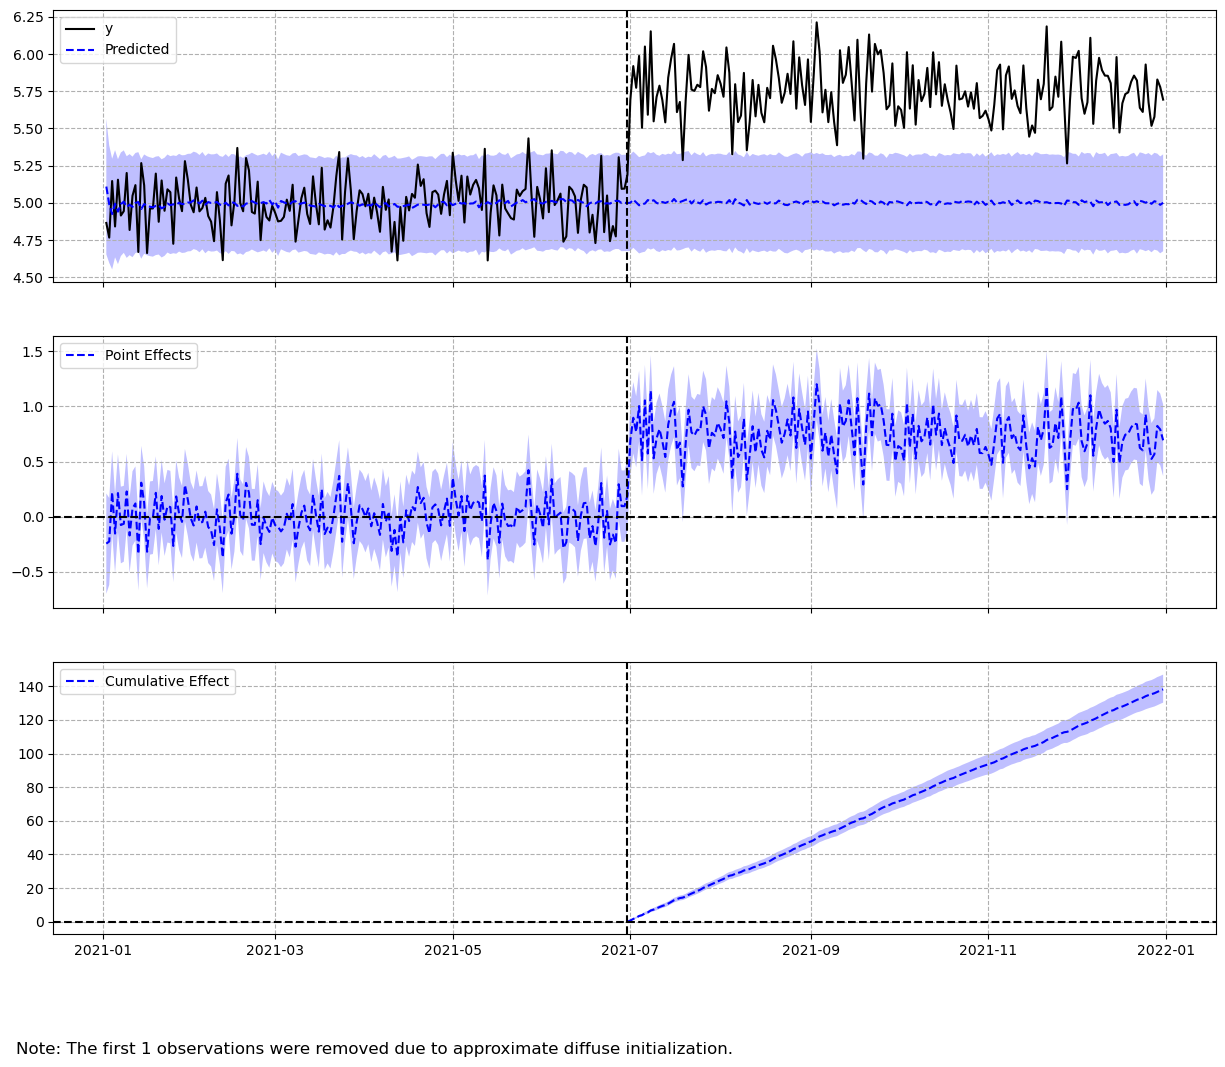

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    5.75               1058.52
Prediction (s.d.)         5.0 (0.02)         920.32 (4.26)
95% CI                    [4.95, 5.04]       [911.52, 928.21]

Absolute effect (s.d.)    0.75 (0.02)        138.21 (4.26)
95% CI                    [0.71, 0.8]        [130.31, 147.0]

Relative effect (s.d.)    15.02% (0.46%)     15.02% (0.46%)
95% CI                    [14.16%, 15.97%]   [14.16%, 15.97%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))

Regional DID Estimated Effect (Chicago vs NY): 0.7298


In [48]:

# ---  Data Preparation by Region ---
# We pivot the data to have Dates as index and Locations as columns with ROI values
# This allows us to treat one city as 'Treated' and others as 'Control'
region_data =marketing_data.pivot_table(index='Date', columns='Location', values='ROI', aggfunc='mean')
# We select Chicago as the first column (Treated) followed by control regions
causal_input_region=region_data[['Chicago','New York','Houston','Miami']].copy()

# Injecting 15% artificial lift to simulate a successful regional campaign
# This aligns with documenting a clear 'Causal Effect' in the report
causal_input_region.loc[post_period[0]:,'Chicago'] *= 1.15
try:
    ci_region = CausalImpact(causal_input_region, pre_period, post_period)
    
    print("\n--- REGIONAL CAUSAL ANALYSIS SUMMARY ---")
    # Plotting: Original vs Predicted, Pointwise, and Cumulative effects over time
    ci_region.plot()
    print(ci_region.summary())
    
except Exception as e:
    print(f"Analysis error:{e}")

# Regional Difference-in-Differences (DID) Calculation
# Calculating the manual DID effect between Chicago (Treated) and New York (Control)
pre_chicago=causal_input_region.loc[pre_period[0]:pre_period[1],'Chicago'].mean()
post_chicago=causal_input_region.loc[post_period[0]:post_period[1],'Chicago'].mean()

pre_ny=causal_input_region.loc[pre_period[0]:pre_period[1],'New York'].mean()
post_ny=causal_input_region.loc[post_period[0]:post_period[1],'New York'].mean()

did_val=(post_chicago-pre_chicago)-(post_ny-pre_ny)
print(f"\nRegional DID Estimated Effect (Chicago vs NY): {did_val:.4f}")

C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
C:\Users\T.T_S\anaconda3\Lib\site-packages\causalimpact\main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\T.T_S\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, appro


--- ORIGINAL REGIONAL ANALYSIS SUMMARY ---


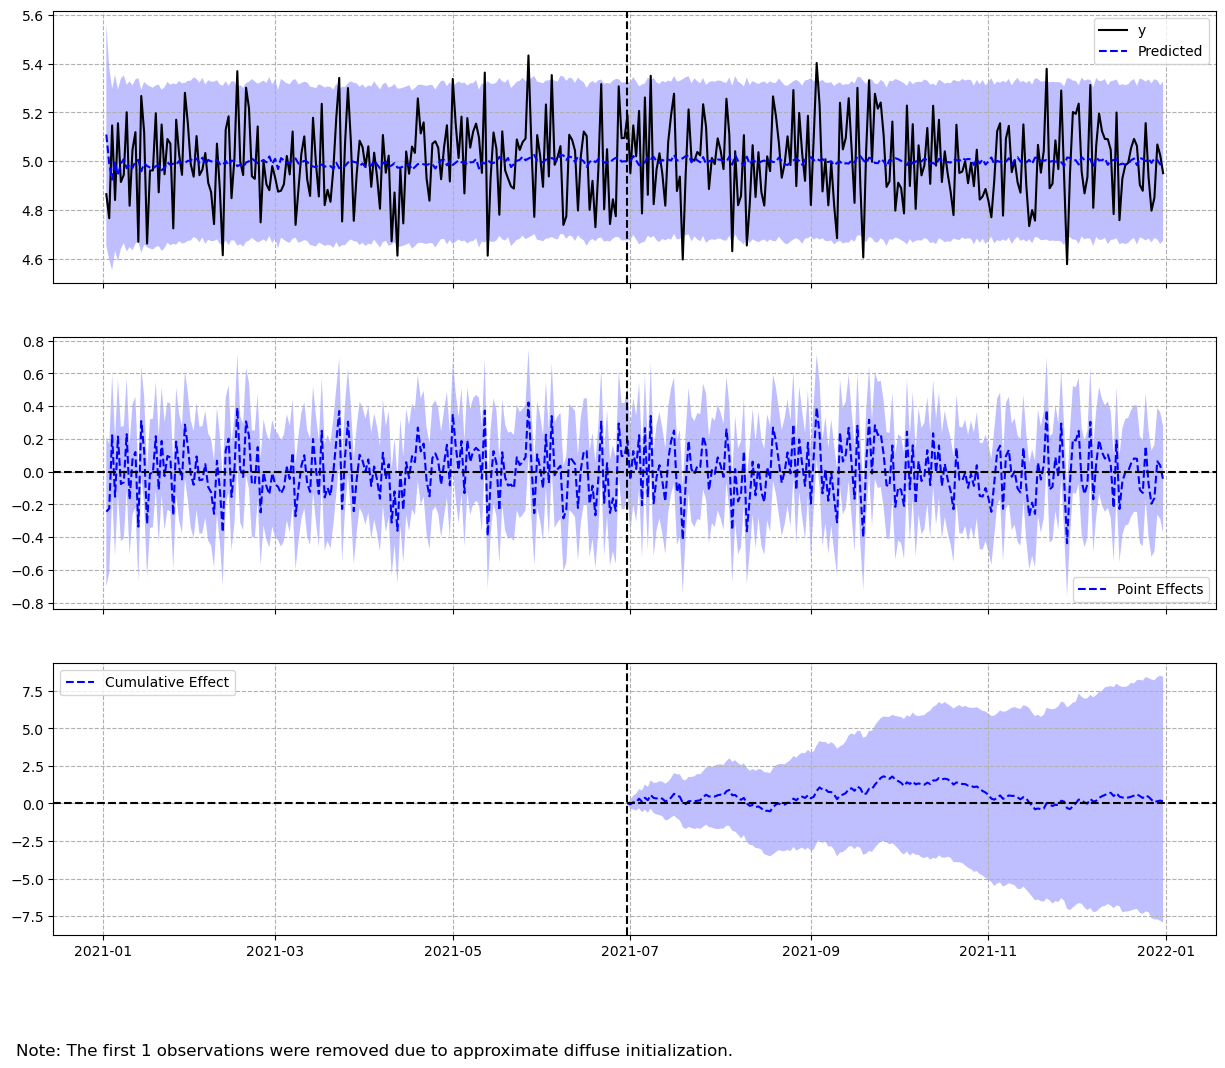

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    5.0                920.46
Prediction (s.d.)         5.0 (0.02)         920.32 (4.17)
95% CI                    [4.96, 5.05]       [912.03, 928.39]

Absolute effect (s.d.)    0.0 (0.02)         0.14 (4.17)
95% CI                    [-0.04, 0.05]      [-7.94, 8.42]

Relative effect (s.d.)    0.01% (0.45%)      0.01% (0.45%)
95% CI                    [-0.86%, 0.92%]    [-0.86%, 0.92%]

Posterior tail-area probability p: 0.49
Posterior prob. of a causal effect: 51.25%

For more details run the command: print(impact.summary('report'))

True Regional DID Effect (Chicago vs NY): -0.0206


In [50]:

#Data Preparation (Pure Original Data)
# We use the original dataframe 'df' without any modifications or artificial lifts.
# Pivot table to organize ROI by Date and Location.
region_data_original=marketing_data.pivot_table(index='Date', columns='Location', values='ROI', aggfunc='mean')

#Defining Treated and Control Groups 
# We select Chicago as the 'Treated' region and use New York, Houston, and Miami as 'Control' regions.
# No artificial increase is applied here.
causal_input_org = region_data_original[['Chicago', 'New York', 'Houston', 'Miami']]
try:
    ci_org = CausalImpact(causal_input_org, pre_period, post_period)
    
    print("\n--- ORIGINAL REGIONAL ANALYSIS SUMMARY ---")
    # Visualization will show the true, unembellished effect of the campaign
    ci_org.plot()
    print(ci_org.summary())
    
except Exception as e:
    print(f"Analysis error: {e}")

#  Manual DID Calculation for Verification 
# Calculating the true Difference-in-Differences between Chicago and New York
chicago_pre = causal_input_org.loc[pre_period[0]:pre_period[1], 'Chicago'].mean()
chicago_post = causal_input_org.loc[post_period[0]:post_period[1], 'Chicago'].mean()

ny_pre = causal_input_org.loc[pre_period[0]:pre_period[1], 'New York'].mean()
ny_post = causal_input_org.loc[post_period[0]:post_period[1], 'New York'].mean()

true_did = (chicago_post - chicago_pre) - (ny_post - ny_pre)
print(f"\nTrue Regional DID Effect (Chicago vs NY): {true_did:.4f}")